# nb08 -- Lasso baseline + skip-connection sparse MLP
Two models, both predicting all 163 proteins jointly from RNA:

1. **Lasso baseline** -- pure linear RNA -> protein, no hidden layer, no nonlinearity, L1-regularized. Gives a transparent floor: if the nonlinear model isn't meaningfully better than this, the nonlinearity isn't earning its keep.
2. **Skip-connection model** -- `protein = direct(RNA) + hidden(RNA)`, where `direct` is a plain linear term (L1-regularized) and `hidden` is the nb07-style RNA -> hidden -> protein path (now with LeakyReLU). The two paths are trained jointly but stay separable at evaluation time, which lets us ask, per protein: is the RNA signal direct, or mediated through other genes?

Same data pipeline as nb06/nb07 (log1p CP10k RNA, CLR protein, library-size correction), so results are comparable across notebooks. Every evaluation reports train and test.

## Environment setup

In [1]:
from pathlib import Path

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    !pip install -q scanpy anndata scikit-misc
    from google.colab import drive
    drive.mount('/content/drive')
    BASE_PATH = Path('/content/drive/MyDrive/covid_citeseq_project')
else:
    BASE_PATH = Path('..')

print(f"Running on {'Colab' if IN_COLAB else 'local'} | BASE_PATH = {BASE_PATH}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Running on Colab | BASE_PATH = /content/drive/MyDrive/covid_citeseq_project


## GPU check

In [2]:
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device (training only):', DEVICE)

Device (training only): cuda


## Imports and config

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import scanpy as sc
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr
from sklearn.metrics import r2_score
import matplotlib.pyplot as plt

CHECKPOINT_PATH    = BASE_PATH / 'data' / 'processed' / 'covid_subsampled.h5ad'
GENE_MAPPING_PATH  = BASE_PATH / 'results' / 'tables' / 'nb02_covid_adt_gene_mapping.csv'
NB07_RESULTS_DIR   = BASE_PATH / 'results' / 'sparse_mlp_v2'
RESULTS_DIR        = BASE_PATH / 'results' / 'sparse_mlp_v3'
MODELS_DIR         = RESULTS_DIR / 'checkpoints'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

N_HVGS       = 2000
DROP_GENES   = ['PDPN', 'KDR']  # zero-variance in GEX (see nb02 Step 3b)

HIDDEN_DIM        = 64
L1_LAMBDA_DIRECT  = 1e-4   # direct RNA -> protein term (both models)
L1_LAMBDA_FC1     = 1e-4   # gene -> hidden (skip model only)
L1_LAMBDA_FC2     = 1e-4   # hidden -> protein (skip model only)
BATCH_SIZE        = 256
NUM_EPOCHS        = 100
PATIENCE           = 15

TEST_SIZE     = 0.15
VAL_SIZE      = 0.15
RANDOM_STATE  = 42

## Load checkpoint and gene mapping

In [4]:
covid = sc.read_h5ad(CHECKPOINT_PATH)

gex_mask = covid.var['feature_types'] == 'Gene Expression'
adt_mask = covid.var['feature_types'] == 'Antibody Capture'
covid_gex = covid[:, gex_mask].copy()
covid_adt = covid[:, adt_mask].copy()

gene_map = pd.read_csv(GENE_MAPPING_PATH)
gene_map = gene_map[~gene_map['gene'].isin(DROP_GENES)]
matched_genes     = gene_map['gene'].tolist()
matched_adt_names = gene_map['adt_name'].tolist()

print(f'GEX: {covid_gex.shape}, ADT: {covid_adt.shape}')
print(f'Matched genes/proteins: {len(matched_genes)}')

GEX: (69090, 24737), ADT: (69090, 192)
Matched genes/proteins: 163


## Gene union (matched + HVG)

In [5]:
covid_gex.layers['counts'] = covid_gex.layers['raw'].copy()

sc.pp.highly_variable_genes(
    covid_gex, n_top_genes=N_HVGS, flavor='seurat_v3', layer='counts',
)
hvg_genes = covid_gex.var_names[covid_gex.var['highly_variable']].tolist()


def build_gene_union(matched_genes: list[str], hvg_genes: list[str]) -> list[str]:
    """Union of matched coupling genes and top HVGs, matched genes always included."""
    return sorted(set(matched_genes) | set(hvg_genes))


gene_union = build_gene_union(matched_genes, hvg_genes)
print(f'Gene union: {len(gene_union)}')

Gene union: 2092


## Normalize and correct (same pipeline as nb06/nb07)
Log1p(CP10k) RNA, CLR protein, library-size regression on both.

In [6]:
def normalize_rna(adata_gex: sc.AnnData, gene_union: list[str]) -> sc.AnnData:
    """Log1p(CP10k) normalization on raw counts, restricted to gene_union."""
    adata = adata_gex[:, gene_union].copy()
    adata.X = adata.layers['raw'].copy()
    sc.pp.normalize_total(adata, target_sum=1e4)
    sc.pp.log1p(adata)
    return adata


def clr_normalize(counts: np.ndarray) -> np.ndarray:
    """Centered log-ratio normalization per cell -- standard for CITE-seq ADT counts."""
    log_counts = np.log1p(counts)
    geometric_mean = log_counts.mean(axis=1, keepdims=True)
    return log_counts - geometric_mean


def regress_out_library_size(X: np.ndarray, raw_counts_layer: np.ndarray) -> np.ndarray:
    """Residualize each column of X against log1p(per-cell total raw counts)."""
    lib_size = np.log1p(np.asarray(raw_counts_layer).sum(axis=1)).reshape(-1, 1)
    design = np.column_stack([np.ones(X.shape[0]), lib_size])
    beta, _, _, _ = np.linalg.lstsq(design, X, rcond=None)
    return (X - design @ beta).astype(np.float32)


rna_adata = normalize_rna(covid_gex, gene_union)
X_rna = np.asarray(rna_adata.X.todense()) if hasattr(rna_adata.X, 'todense') else np.asarray(rna_adata.X)
X_rna = X_rna.astype(np.float32)

adt_counts = covid_adt[:, matched_adt_names].layers['raw']
adt_counts = np.asarray(adt_counts.todense()) if hasattr(adt_counts, 'todense') else np.asarray(adt_counts)
Y_protein = clr_normalize(adt_counts).astype(np.float32)

rna_raw_for_size = rna_adata.layers['raw']
rna_raw_for_size = np.asarray(rna_raw_for_size.todense()) if hasattr(rna_raw_for_size, 'todense') else np.asarray(rna_raw_for_size)

X_rna_corr     = regress_out_library_size(X_rna, rna_raw_for_size)
Y_protein_corr = regress_out_library_size(Y_protein, adt_counts)

print(f'X_rna_corr: {X_rna_corr.shape} | Y_protein_corr: {Y_protein_corr.shape}')

X_rna_corr: (69090, 2092) | Y_protein_corr: (69090, 163)


## Train / val / test split

In [7]:
n_cells = X_rna_corr.shape[0]
all_idx = np.arange(n_cells)

train_idx, test_idx = train_test_split(all_idx, test_size=TEST_SIZE, random_state=RANDOM_STATE)
train_idx, val_idx  = train_test_split(train_idx, test_size=VAL_SIZE / (1 - TEST_SIZE), random_state=RANDOM_STATE)

print(f'Train: {len(train_idx):,} | Val: {len(val_idx):,} | Test: {len(test_idx):,}')

Train: 48,362 | Val: 10,364 | Test: 10,364


## DataLoaders

In [8]:
def make_loader(X: np.ndarray, Y: np.ndarray, idx: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    ds = TensorDataset(torch.from_numpy(X[idx]), torch.from_numpy(Y[idx]))
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle, drop_last=shuffle)


train_loader = make_loader(X_rna_corr, Y_protein_corr, train_idx, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_rna_corr, Y_protein_corr, val_idx,   BATCH_SIZE, shuffle=False)

## Model architectures
`LassoLinear`: no hidden layer, no nonlinearity -- pure L1-regularized linear regression, trained by gradient descent instead of coordinate descent, but equivalent in spirit to per-protein Lasso.

`SkipConnectionSparseMLP`: `direct(RNA) + hidden(RNA)`. `forward_components` exposes the two paths separately so their contributions can be decomposed after training.

In [9]:
class LassoLinear(nn.Module):
    """Pure linear RNA -> protein, no hidden layer, no nonlinearity. The Lasso baseline."""

    def __init__(self, rna_dim: int, protein_dim: int):
        super().__init__()
        self.linear = nn.Linear(rna_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.linear(x)


class SkipConnectionSparseMLP(nn.Module):
    """RNA -> protein via a direct linear term plus a hidden nonlinear term.

    rna_dim     : number of input genes.
    hidden_dim  : hidden layer width (mediated path only).
    protein_dim : number of output proteins, predicted jointly.
    """

    def __init__(self, rna_dim: int, hidden_dim: int, protein_dim: int):
        super().__init__()
        self.direct = nn.Linear(rna_dim, protein_dim)
        self.fc1 = nn.Linear(rna_dim, hidden_dim)
        self.activation = nn.LeakyReLU(negative_slope=0.01)
        self.fc2 = nn.Linear(hidden_dim, protein_dim)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        direct_pred, hidden_pred = self.forward_components(x)
        return direct_pred + hidden_pred

    def forward_components(self, x: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
        """Direct and hidden-path predictions, kept separate for decomposition."""
        direct_pred = self.direct(x)
        hidden_pred = self.fc2(self.activation(self.fc1(x)))
        return direct_pred, hidden_pred

## Training loop -- generic over L1 penalty
Same GPU-train / CPU-validate device pattern as nb06/nb07. The L1 penalty is passed in as a function of the model, so the same loop trains both architectures without duplication.

In [11]:
def fit_model(model: nn.Module,
              train_loader: DataLoader,
              val_loader: DataLoader,
              l1_penalty_fn,
              num_epochs: int,
              patience: int,
              checkpoint_path: Path,
              train_device: torch.device,
              verbose: bool = True):
    """Train with MSE + l1_penalty_fn(model) on train_device; validate on CPU each epoch."""
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)
    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')
    best_state = None
    epochs_no_improve = 0

    for epoch in range(num_epochs):
        model.to(train_device)
        model.train()
        total_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(train_device), yb.to(train_device)
            optimizer.zero_grad()
            pred = model(xb)
            loss = criterion(pred, yb) + l1_penalty_fn(model)
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * xb.size(0)
        train_loss = total_loss / len(train_loader.dataset)

        model.to('cpu')
        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                val_loss += criterion(model(xb), yb).item() * xb.size(0)
        val_loss /= len(val_loader.dataset)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                if verbose:
                    print(f'  Early stopping at epoch {epoch}')
                break

        if verbose and epoch % 10 == 0:
            print(f'  Epoch {epoch}: train_loss={train_loss:.4f}, val_loss={val_loss:.4f}')

    model.load_state_dict(best_state)
    model.to('cpu')
    torch.save(model.state_dict(), checkpoint_path)
    return model, history


def lasso_l1_penalty(model: LassoLinear) -> torch.Tensor:
    return L1_LAMBDA_DIRECT * model.linear.weight.abs().sum()


def skip_l1_penalty(model: SkipConnectionSparseMLP) -> torch.Tensor:
    return (L1_LAMBDA_DIRECT * model.direct.weight.abs().sum()
            + L1_LAMBDA_FC1 * model.fc1.weight.abs().sum()
            + L1_LAMBDA_FC2 * model.fc2.weight.abs().sum())

## Train the Lasso baseline

In [12]:
print('Training Lasso baseline (no hidden layer)...')
lasso_model = LassoLinear(rna_dim=X_rna_corr.shape[1], protein_dim=Y_protein_corr.shape[1])
lasso_model, lasso_history = fit_model(
    model=lasso_model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_penalty_fn=lasso_l1_penalty,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'lasso_baseline.pt',
    train_device=DEVICE,
)

Training Lasso baseline (no hidden layer)...
  Epoch 0: train_loss=0.3554, val_loss=0.2791
  Epoch 10: train_loss=0.3089, val_loss=0.2783
  Epoch 20: train_loss=0.3091, val_loss=0.2784
  Early stopping at epoch 24


## Train the skip-connection model

In [13]:
print('Training skip-connection model (direct + hidden)...')
skip_model = SkipConnectionSparseMLP(
    rna_dim=X_rna_corr.shape[1], hidden_dim=HIDDEN_DIM, protein_dim=Y_protein_corr.shape[1],
)
skip_model, skip_history = fit_model(
    model=skip_model,
    train_loader=train_loader,
    val_loader=val_loader,
    l1_penalty_fn=skip_l1_penalty,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE,
    checkpoint_path=MODELS_DIR / 'skip_connection_model.pt',
    train_device=DEVICE,
)

Training skip-connection model (direct + hidden)...
  Epoch 0: train_loss=0.3981, val_loss=0.2735
  Epoch 10: train_loss=0.3040, val_loss=0.2697
  Epoch 20: train_loss=0.3035, val_loss=0.2689
  Epoch 30: train_loss=0.3033, val_loss=0.2688
  Epoch 40: train_loss=0.3033, val_loss=0.2690
  Early stopping at epoch 41


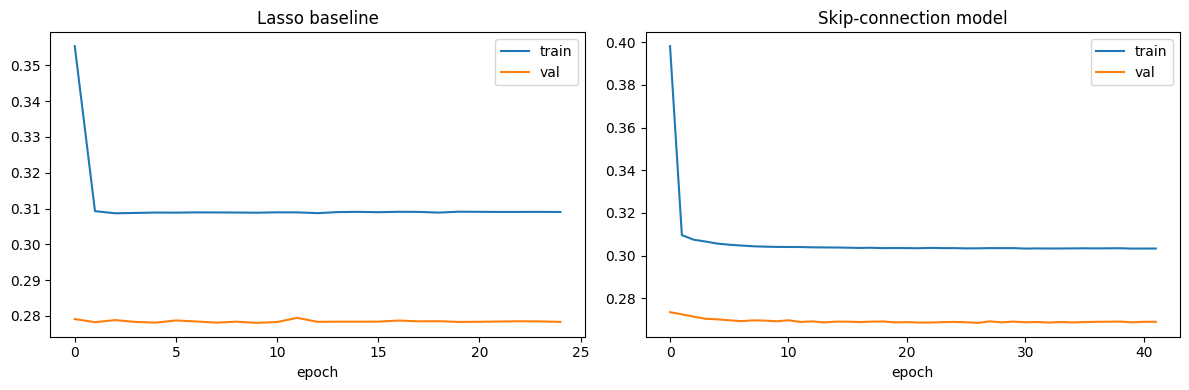

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(lasso_history['train_loss'], label='train')
axes[0].plot(lasso_history['val_loss'], label='val')
axes[0].set_title('Lasso baseline')
axes[0].set_xlabel('epoch')
axes[0].legend()

axes[1].plot(skip_history['train_loss'], label='train')
axes[1].plot(skip_history['val_loss'], label='val')
axes[1].set_title('Skip-connection model')
axes[1].set_xlabel('epoch')
axes[1].legend()
plt.tight_layout()
plt.show()

## Evaluation (CPU only, train and test both)
Same convention as nb06/nb07 -- every metric reported on both splits.

In [15]:
def evaluate_per_protein(model: nn.Module, X: np.ndarray, Y: np.ndarray, protein_names: list[str]) -> pd.DataFrame:
    """Per-protein Pearson r and R2 on CPU."""
    model.to('cpu')
    model.eval()
    with torch.no_grad():
        preds = model(torch.from_numpy(X)).numpy()
    rows = []
    for i, name in enumerate(protein_names):
        r, _ = pearsonr(Y[:, i], preds[:, i])
        r2 = r2_score(Y[:, i], preds[:, i])
        rows.append({'protein': name, 'pearson_r': r, 'r2': r2})
    return pd.DataFrame(rows)


def train_test_metrics(model: nn.Module, protein_names: list[str]) -> pd.DataFrame:
    """Merge train and test per-protein metrics into one table with the train-test gap."""
    train_m = evaluate_per_protein(model, X_rna_corr[train_idx], Y_protein_corr[train_idx], protein_names)
    test_m  = evaluate_per_protein(model, X_rna_corr[test_idx],  Y_protein_corr[test_idx],  protein_names)
    merged = train_m.merge(test_m, on='protein', suffixes=('_train', '_test'))
    merged['r_gap'] = merged['pearson_r_train'] - merged['pearson_r_test']
    return merged.sort_values('pearson_r_test', ascending=False).reset_index(drop=True)


lasso_metrics = train_test_metrics(lasso_model, matched_adt_names)
skip_metrics  = train_test_metrics(skip_model, matched_adt_names)

print(f"Lasso baseline      -- median test r: {lasso_metrics['pearson_r_test'].median():.3f}")
print(f"Skip-connection     -- median test r: {skip_metrics['pearson_r_test'].median():.3f}")

try:
    nb07_metrics = pd.read_csv(NB07_RESULTS_DIR / 'global_per_protein_metrics.csv')
    print(f"nb07 (hidden-only)  -- median test r: {nb07_metrics['pearson_r_test'].median():.3f}")
except FileNotFoundError:
    nb07_metrics = None
    print('nb07 results not found -- skipping three-way comparison.')

Lasso baseline      -- median test r: 0.366
Skip-connection     -- median test r: 0.387
nb07 (hidden-only)  -- median test r: 0.397


In [16]:
comparison = lasso_metrics[['protein', 'pearson_r_test']].rename(columns={'pearson_r_test': 'lasso_r_test'}).merge(
    skip_metrics[['protein', 'pearson_r_test']].rename(columns={'pearson_r_test': 'skip_r_test'}), on='protein',
)
if nb07_metrics is not None:
    comparison = comparison.merge(
        nb07_metrics[['protein', 'pearson_r_test']].rename(columns={'pearson_r_test': 'hidden_only_r_test'}),
        on='protein',
    )
comparison['skip_vs_lasso_gain'] = comparison['skip_r_test'] - comparison['lasso_r_test']
comparison = comparison.sort_values('skip_vs_lasso_gain', ascending=False)

print(f"Median gain from adding hidden path over pure Lasso: {comparison['skip_vs_lasso_gain'].median():.3f}")
comparison.head(20)

Median gain from adding hidden path over pure Lasso: 0.020


,protein,lasso_r_test,skip_r_test,hidden_only_r_test,skip_vs_lasso_gain
128,AB_CDH5,0.174577,0.300414,0.327755,0.125836
98,AB_THY1,0.288418,0.413196,0.439418,0.124778
150,AB_HLA-F,0.112240,0.230638,0.249039,0.118398
161,AB_CLEC9A,0.066066,0.177137,0.191431,0.111071
132,AB_c-Met,0.161598,0.272005,0.305374,0.110408
99,AB_CD40LG,0.277340,0.386472,0.403279,0.109131
50,AB_ICAM1,0.515080,0.624137,0.628177,0.109057
101,AB_SIGLEC1,0.262363,0.361457,0.394217,0.099094
123,AB_MSR1,0.185848,0.284622,0.304549,0.098774
131,AB_DR3,0.164460,0.262104,0.281383,0.097644


## Direct vs. hidden-path contribution decomposition
For the skip-connection model: how much of each protein's prediction comes from the direct linear term vs. the hidden (mediated) term. High `direct_r`, low `hidden_r` means the protein's signal is basically direct linear regulation by RNA; the reverse means it needs other genes to explain it.

In [17]:
def decompose_contributions(model: SkipConnectionSparseMLP, X: np.ndarray, Y: np.ndarray,
                             protein_names: list[str]) -> pd.DataFrame:
    """Per-protein Pearson r of the direct-only and hidden-only prediction components
    against the real value, plus each component's share of prediction variance.
    """
    model.to('cpu')
    model.eval()
    with torch.no_grad():
        direct_pred, hidden_pred = model.forward_components(torch.from_numpy(X))
    direct_pred, hidden_pred = direct_pred.numpy(), hidden_pred.numpy()

    rows = []
    for i, protein in enumerate(protein_names):
        real = Y[:, i]
        d, h = direct_pred[:, i], hidden_pred[:, i]
        direct_r = pearsonr(real, d)[0] if np.std(d) > 0 else np.nan
        hidden_r = pearsonr(real, h)[0] if np.std(h) > 0 else np.nan
        var_d, var_h = d.var(), h.var()
        rows.append({
            'protein': protein,
            'direct_r': direct_r,
            'hidden_r': hidden_r,
            'direct_var_share': var_d / (var_d + var_h + 1e-12),
        })
    return pd.DataFrame(rows).sort_values('direct_var_share', ascending=False)


decomposition = decompose_contributions(skip_model, X_rna_corr[test_idx], Y_protein_corr[test_idx], matched_adt_names)
print(f"Median direct-path variance share: {decomposition['direct_var_share'].median():.2f}")
decomposition.head(20)

Median direct-path variance share: 0.50


,protein,direct_r,hidden_r,direct_var_share
88,AB_ITGB7,0.392708,0.118507,0.995054
146,AB_SLAMF1,0.310965,0.180369,0.987022
135,AB_KIR3DL1,0.364606,0.175969,0.980968
30,AB_CCR4,0.481839,0.135857,0.974372
56,AB_CD161,0.506721,0.151735,0.968406
70,AB_B3GAT1,0.534598,-0.012367,0.967046
126,AB_CD304,0.137376,0.077116,0.965647
103,AB_CXCR4,0.156760,0.008883,0.955316
145,AB_KLRD1,0.688216,0.522841,0.955176
78,AB_CX3CR1,0.393444,0.148439,0.954524


## Cognate gene rank, direct path only
Because `direct` is a plain linear layer, its weight matrix is directly interpretable -- no path-weight product needed. This is a cleaner test of whether the cognate RNA has a genuine *direct* effect, separate from mediated effects captured in the hidden path.

In [18]:
def cognate_gene_rank(importance_df: pd.DataFrame, gene_map: pd.DataFrame) -> pd.DataFrame:
    """Rank of each protein's cognate RNA gene by importance score (1 = top predictor)."""
    rows = []
    for _, row in gene_map.iterrows():
        gene, adt = row['gene'], row['adt_name']
        if adt not in importance_df.index or gene not in importance_df.columns:
            continue
        ranks = importance_df.loc[adt].rank(ascending=False)
        top_gene = importance_df.loc[adt].idxmax()
        rows.append({
            'protein': adt, 'cognate_gene': gene, 'cognate_rank': int(ranks[gene]),
            'n_genes': len(ranks), 'top_predictor_gene': top_gene,
        })
    return pd.DataFrame(rows).sort_values('cognate_rank').reset_index(drop=True)


W_direct = skip_model.direct.weight.detach().numpy()  # (protein_dim, rna_dim)
direct_importance_df = pd.DataFrame(np.abs(W_direct), index=matched_adt_names, columns=gene_union)

direct_cognate_ranks = cognate_gene_rank(direct_importance_df, gene_map)
print(f"Proteins where cognate RNA is #1 in the DIRECT path: "
      f"{(direct_cognate_ranks['cognate_rank'] == 1).sum()} / {len(direct_cognate_ranks)}")
print('(nb07, path-weight through hidden-only model, was 6/163 -- if this number is higher, '
      'the direct term is recovering genuine 1:1 regulation that the hidden-only model was diluting)')
direct_cognate_ranks.head(20)

Proteins where cognate RNA is #1 in the DIRECT path: 44 / 163
(nb07, path-weight through hidden-only model, was 6/163 -- if this number is higher, the direct term is recovering genuine 1:1 regulation that the hidden-only model was diluting)


,protein,cognate_gene,cognate_rank,n_genes,top_predictor_gene
0,AB_CD40,CD40,1,2092,CD40
1,AB_CD52,CD52,1,2092,CD52
2,AB_CCR4,CCR4,1,2092,CCR4
3,AB_CD7,CD7,1,2092,CD7
4,AB_ITGAX,ITGAX,1,2092,ITGAX
5,AB_CD34,CD34,1,2092,CD34
6,AB_CD56,NCAM1,1,2092,NCAM1
7,AB_CD8,CD8A,1,2092,CD8A
8,AB_CD123,IL3RA,1,2092,IL3RA
9,AB_CD5,CD5,1,2092,CD5


## Save results

In [19]:
lasso_metrics.to_csv(RESULTS_DIR / 'lasso_per_protein_metrics.csv', index=False)
skip_metrics.to_csv(RESULTS_DIR / 'skip_per_protein_metrics.csv', index=False)
comparison.to_csv(RESULTS_DIR / 'lasso_vs_skip_comparison.csv', index=False)
decomposition.to_csv(RESULTS_DIR / 'direct_vs_hidden_decomposition.csv', index=False)
direct_cognate_ranks.to_csv(RESULTS_DIR / 'direct_path_cognate_ranks.csv', index=False)
direct_importance_df.to_parquet(RESULTS_DIR / 'direct_path_importance.parquet')

print(f'Saved to {RESULTS_DIR}')
print('  lasso_per_protein_metrics.csv        -- Lasso baseline, train/test Pearson r + R2')
print('  skip_per_protein_metrics.csv         -- skip-connection model, train/test Pearson r + R2')
print('  lasso_vs_skip_comparison.csv         -- per-protein gain from adding the hidden path')
print('  direct_vs_hidden_decomposition.csv   -- direct vs. hidden contribution per protein')
print('  direct_path_cognate_ranks.csv        -- cognate RNA rank, direct path only')
print('  direct_path_importance.parquet       -- full direct-path weight matrix')

Saved to /content/drive/MyDrive/covid_citeseq_project/results/sparse_mlp_v3
  lasso_per_protein_metrics.csv        -- Lasso baseline, train/test Pearson r + R2
  skip_per_protein_metrics.csv         -- skip-connection model, train/test Pearson r + R2
  lasso_vs_skip_comparison.csv         -- per-protein gain from adding the hidden path
  direct_vs_hidden_decomposition.csv   -- direct vs. hidden contribution per protein
  direct_path_cognate_ranks.csv        -- cognate RNA rank, direct path only
  direct_path_importance.parquet       -- full direct-path weight matrix
